## Libraries and Packages

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import nltk
from nltk import word_tokenize, pos_tag
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

import folium
from folium.plugins import MarkerCluster
import geopandas as gpd
from shapely.geometry import Point

from urllib.parse import urlparse
from IPython.display import display, HTML

## Dataframe Creation and Exploratory Data Analysis (EDA)
In this section, the dataframe is initialized from the raw hotel reviews CSV file. Following data ingestion, preliminary analysis is conducted to understand the structural integrity, schema, and core characteristics of the dataset.

In [4]:
df = pd.read_csv('Datafiniti_Hotel_Reviews.csv')

In [5]:
df.shape

(10000, 25)

In [6]:
df.columns

Index(['id', 'dateAdded', 'dateUpdated', 'address', 'categories',
       'primaryCategories', 'city', 'country', 'keys', 'latitude', 'longitude',
       'name', 'postalCode', 'province', 'reviews.date', 'reviews.dateSeen',
       'reviews.rating', 'reviews.sourceURLs', 'reviews.text', 'reviews.title',
       'reviews.userCity', 'reviews.userProvince', 'reviews.username',
       'sourceURLs', 'websites'],
      dtype='object')

In [7]:
# Display the first few rows to inspect the dataset structure
df.sample(5)

,id,dateAdded,dateUpdated,address,categories,primaryCategories,city,country,keys,latitude,...,reviews.dateSeen,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username,sourceURLs,websites
5887,AVwch2Y8ByjofQCxfPWJ,2016-07-18T19:42:01Z,2018-03-18T19:41:48Z,1033 Main St,"Hotels,Lodging,Motels,Corporate Lodging,Hotel",Accommodation & Food Services,Springfield,US,us/co/springfield/1033mainst/519316916,37.403740,...,2016-07-18T00:00:00Z,3.00,https://www.tripadvisor.com/Hotel_Review-g3365...,We stayed at the Stage Stop Hotel on a Friday ...,Step back in time,Colorado Springs,CO,becky472014,https://www.yellowpages.com/springfield-co/mip...,http://www.stagestophotel.com
4807,AVweUjWf_7pvs4fzB9tn,2016-04-05T14:11:53Z,2018-04-10T06:44:42Z,1960 Broadway,"Resort,Hotels,Hotels and motels,Resorts,Luxury...",Accommodation & Food Services,Orlando,US,us/fl/orlando/1960broadway/-1423839458,28.376000,...,2015-05-20T00:00:00Z,3.00,http://www.tripadvisor.com/Hotel_Review-g34515...,We stayed a week while visiting Disney. We had...,Nice room - housekeeping issues,NaN,NaN,prizepig,https://foursquare.com/v/disneys-saratoga-spri...,http://disneyworld.disney.go.com/resorts/sarat...
5910,AVweCk9q_7pvs4fz_gzl,2016-11-18T15:48:05Z,2018-03-18T04:47:53Z,1881 Highway 101 N,"Motel,Hotels and motels,Hotels Motels,Hotels,L...",Accommodation & Food Services,Yachats,US,us/or/yachats/1881highway101n/1903738572,44.322600,...,2016-03-23T00:00:00Z,5.00,http://www.tripadvisor.com/Hotel_Review-g52148...,"At the coast for a family event, we needed a p...",A comfortable place to escape,Albany,OR,LadybugDadeh,https://foursquare.com/v/fireside-motel/4bc424...,http://www.firesidemotel.com
6607,AVwc56Le_7pvs4fz0Nb_,2015-10-19T16:07:12Z,2018-03-07T19:07:35Z,4343 Collins Ave,"Hotel,Hotels,Hotels and motels,Hotels Motels,F...",Accommodation & Food Services,Miami Beach,US,us/fl/miamibeach/4343collinsave/482884630,25.815437,...,"2016-06-15T00:00:00Z,2016-07-25T00:00:00Z,2016...",4.00,https://www.tripadvisor.com/Hotel_Review-g3443...,"Pros: Hotel - On the beach, on the boardwalk, ...","Beach, Boardwalk.",Houston,TX,KellyinKaty,https://foursquare.com/v/four-points-by-sherat...,"http://www.fourpointsmiamibeach.com?SWAQ=94ZA,..."
564,AWKkrZYpa4HuVbedPT1I,2018-04-08T09:00:00Z,2018-09-04T21:27:48Z,160 East Flamingo Road,"Hotels,Hotel",Accommodation & Food Services,Las Vegas,US,us/nv/lasvegas/160eastflamingoroad/-1348544144,36.115137,...,2018-03-29T00:00:00Z,3.75,https://www.booking.com/reviews/us/hotel/westi...,Good: Central location. Nice cafe and a Starbu...,Great location off the strip.,NaN,NaN,Rosemary,https://www.booking.com/reviews/us/hotel/westi...,http://www.westinvegas.com/


In [8]:
# Generate summary statistics for numerical features
df.describe()

,latitude,longitude,reviews.rating
count,10000.000000,10000.000000,10000.000000
mean,37.003630,-92.675934,4.034265
std,5.517273,19.347989,1.162240
min,19.438604,-159.474930,1.000000
25%,33.927588,-111.622343,3.350000
50%,37.785060,-84.452114,4.000000
75%,40.416380,-77.052700,5.000000
max,70.133620,-68.203990,5.000000


Several actionable insights can be derived from this summary statistics table. Notably, the review ratings range strictly between 0 and 5, confirming there are no out-of-bounds values or anomalies requiring immediate correction. Additionally, the geographical coordinate ranges (latitude and longitude) appear consistent and valid based on this preliminary check.

In [10]:
# Check data types and identify missing (null) values across columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    10000 non-null  object 
 1   dateAdded             10000 non-null  object 
 2   dateUpdated           10000 non-null  object 
 3   address               10000 non-null  object 
 4   categories            10000 non-null  object 
 5   primaryCategories     10000 non-null  object 
 6   city                  10000 non-null  object 
 7   country               10000 non-null  object 
 8   keys                  10000 non-null  object 
 9   latitude              10000 non-null  float64
 10  longitude             10000 non-null  float64
 11  name                  10000 non-null  object 
 12  postalCode            10000 non-null  object 
 13  province              10000 non-null  object 
 14  reviews.date          10000 non-null  object 
 15  reviews.dateSeen    

In [11]:
# Verify the presence of duplicate rows in the dataframe
somma_duplicati = df.duplicated().sum()
somma_duplicati

0

### Temporal Analysis
This section focuses on identifying the time span and collection periods of the dataset. To perform an accurate chronological analysis, data formatting and date-time conversions will be required.

In [13]:
# New dataframe focused on dates
df_date = df[['id','name','dateAdded', 'dateUpdated','reviews.date']].copy()

In [14]:
df_date.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            10000 non-null  object
 1   name          10000 non-null  object
 2   dateAdded     10000 non-null  object
 3   dateUpdated   10000 non-null  object
 4   reviews.date  10000 non-null  object
dtypes: object(5)
memory usage: 390.8+ KB


In [15]:
# 1. List of columns to convert
colonne_data = ['dateAdded', 'dateUpdated', 'reviews.date']

In [16]:
# 2. Convert date columns to datetime format
for col in colonne_data:
    df_date[col] = pd.to_datetime(df_date[col], errors='coerce')
    # Dynamically generate temporal features (e.g., month, year) from dates
    df_date[f'{col}_month'] = df_date[col].dt.month
    df_date[f'{col}_year'] = df_date[col].dt.year

In [17]:
df_date = df_date.drop(['reviews.date', 'dateAdded', 'dateUpdated'], axis=1)

In [18]:
# checking how the dataframe looks after the changes
df_date.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  10000 non-null  object 
 1   name                10000 non-null  object 
 2   dateAdded_month     10000 non-null  int32  
 3   dateAdded_year      10000 non-null  int32  
 4   dateUpdated_month   10000 non-null  int32  
 5   dateUpdated_year    10000 non-null  int32  
 6   reviews.date_month  6165 non-null   float64
 7   reviews.date_year   6165 non-null   float64
dtypes: float64(2), int32(4), object(2)
memory usage: 468.9+ KB


In [19]:
df_date['dateAdded_year'].unique()

array([2016, 2015, 2018, 2017, 2014])

In [20]:
df_date['dateAdded_year'].value_counts()

dateAdded_year
2016    4828
2017    2434
2018    1464
2015    1271
2014       3
Name: count, dtype: int64

In [21]:
df_date['dateUpdated_year'].unique()

array([2018])

In [22]:
df_date['dateUpdated_month'].unique()

array([9, 8, 7, 6, 5, 4, 3, 2, 1])

In [23]:
df_date['dateUpdated_month'].value_counts()

dateUpdated_month
1    2735
3    1822
9    1080
4     959
5     944
8     928
6     926
2     516
7      90
Name: count, dtype: int64

In [24]:
df_date['reviews.date_year'].value_counts()

reviews.date_year
2016.0    3374
2015.0    2181
2014.0     325
2013.0     112
2012.0      73
2011.0      52
2009.0      17
2010.0      13
2008.0       7
2007.0       5
2006.0       2
2005.0       2
2002.0       1
2004.0       1
Name: count, dtype: int64

**Key Findings from Temporal Analysis:**
* **Database Ingestion (dateAdded).** Hotel reviews were populated into the database between 2014 and 2017, with a significant data density concentration occurring in 2016.
* **System Updates (dateUpdated).** Record updates are strictly confined to 2018, freezing after September. No subsequent modifications are recorded in the final months of that year, establishing September 2018 as the dataset's final maintenance cutoff.
* **Review Timeline (reviews.date).** While individual review timestamps span from 2004 to 2016, historical data from the early years is extremely sparse. In contrast, a massive volume shift is visible in the later period, with over 50% of all reviews concentrated within 2015 and 2016.

## Geographical Location and Rating Dynamics

### Preliminary Spatial Analysis: Hotels and Regional Distribution
This section examines the spatial distribution of the hotels within the dataset to investigate whether geographical location correlates with user ratings. Additionally, we will evaluate regional performance metrics to identify if specific states consistently achieve higher average scores than others.

As a foundational step, we will first quantify the exact volume of unique hotels and determine their distribution across the different states.

In [27]:
df['country'].value_counts()

country
US    10000
Name: count, dtype: int64

In [28]:
df['name'].value_counts()

name
Metro Points Hotel-Washington North    202
The Westin Las Vegas Hotel & Spa       171
Best Western Springfield               160
ARIA Resort Casino                     139
Kinzie Hotel                           138
                                      ... 
Kalispell Grand Hotel                    1
Holiday Inn Express & Suites Helena      1
Best Western Greentree Inn & Suites      1
Diamond Inn                              1
Royal Suite Lodge                        1
Name: count, Length: 1670, dtype: int64

In [29]:
df['province'].value_counts()

province
VA    1096
CA    1053
MD     896
FL     877
NV     541
IL     465
MA     336
PA     315
SC     297
TX     291
GA     281
LA     239
WA     237
NY     213
AZ     212
HI     212
TN     176
OH     171
OR     171
WI     165
MO     152
CO     134
KY     124
NJ     119
NC     117
MI     103
OK      98
IN      97
ME      77
NM      70
KS      58
ID      56
DE      56
MT      54
IA      51
NE      45
MN      41
NH      38
WY      37
WV      35
AR      33
SD      33
CT      30
AK      21
UT      20
MS      20
ND      18
VT      14
RI       5
Name: count, dtype: int64

So we understand that the hotels considered are 1670, all in the United States, and that the states considered are 49, all indicated with acronyms.

### Interactive hotel map

In [32]:
# State code-to-name mapping dictionary (reused in subsequent steps)
us_state_to_abbrev = {
    "Alabama": "AL", "Alaska": "AK", "Arizona": "AZ", "Arkansas": "AR", "California": "CA",
    "Colorado": "CO", "Connecticut": "CT", "Delaware": "DE", "Florida": "FL", "Georgia": "GA",
    "Hawaii": "HI", "Idaho": "ID", "Illinois": "IL", "Indiana": "IN", "Iowa": "IA",
    "Kansas": "KS", "Kentucky": "KY", "Louisiana": "LA", "Maine": "ME", "Maryland": "MD",
    "Massachusetts": "MA", "Michigan": "MI", "Minnesota": "MN", "Mississippi": "MS", "Missouri": "MO",
    "Montana": "MT", "Nebraska": "NE", "Nevada": "NV", "New Hampshire": "NH", "New Jersey": "NJ",
    "New Mexico": "NM", "New York": "NY", "North Carolina": "NC", "North Dakota": "ND", "Ohio": "OH",
    "Oklahoma": "OK", "Oregon": "OR", "Pennsylvania": "PA", "Rhode Island": "RI", "South Carolina": "SC",
    "South Dakota": "SD", "Tennessee": "TN", "Texas": "TX", "Utah": "UT", "Vermont": "VT",
    "Virginia": "VA", "Washington": "WA", "West Virginia": "WV", "Wisconsin": "WI", "Wyoming": "WY",
    "District of Columbia": "DC"
}

# Invert dictionary to map abbreviation to full state name (e.g., {'CA': 'California'})
abbrev_to_us_state = {v: k for k, v in us_state_to_abbrev.items()}

In [33]:
# Step 1: Data Preprocessing - Batch URL cleaning across the entire dataframe
df['clean_url'] = df['reviews.sourceURLs'].str.split(',').str[0].str.replace(r'[\[\]"]', '', regex=True).str.strip()

# Step 2: Data Aggregation - Single-pass statistical summary
state_stats = df.groupby('province')['reviews.rating'].mean().round(2)
state_averages_dict = state_stats.to_dict()

# Step 3: Hotel Aggregation
hotel_map_data = df.groupby('name').agg({
    'latitude': 'mean',
    'longitude': 'mean',
    'reviews.rating': 'mean',
    'province': 'first',
    'city': 'first',
    'clean_url': 'first' # Let's use the cleaned URL
}).dropna(subset=['latitude', 'longitude'])

# Step 4. # Simplified helper functions
def get_color(rating):
    if rating <= 2: return 'red'
    if rating <= 3.5: return 'orange'
    if rating <= 4.5: return 'green'
    return 'darkgreen'

def get_hotel_info(name, rating, province_abbrev, city, url):
    state_avg = state_averages_dict.get(province_abbrev, 0)
    diff = rating - state_avg
    color_diff = "green" if diff >= 0 else "red"
    link_html = f'<br><a href="{url}" target="_blank">Vedi Recensione</a>' if pd.notna(url) else ""

    return f"""
    <div style="font-family: Arial; width: 200px;">
        <h4>{name}</h4>
        <b>Città:</b> {city}<br>
        <b>Rating:</b> {rating:.2f} <hr>
        <b>Media Stato ({province_abbrev}):</b> {state_avg:.2f}<br>
        <span style="color:{color_diff};"><b>Diff:</b> {diff:+.2f}</span>
        {link_html}
    </div>
    """

# Step 5. Map
m_completa = folium.Map(location=[37.0902, -95.7129], zoom_start=4, tiles='CartoDB positron')

# Choropleth
folium.Choropleth(
    geo_data='https://raw.githubusercontent.com/python-visualization/folium/master/examples/data/us-states.json',
    data=state_stats.reset_index(), # Usiamo state_stats calcolato prima
    columns=['province', 'reviews.rating'],
    key_on='feature.id',
    fill_color='RdYlGn',
    fill_opacity=0.4,
    line_opacity=0.2,
    legend_name='Average quality by state'
).add_to(m_completa)

# Marker
for name, row in hotel_map_data.iterrows():
    popup_content = get_hotel_info(name, row['reviews.rating'], row['province'], row['city'], row['clean_url'])
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=5,
        popup=folium.Popup(popup_content, max_width=300),
        color='black', weight=0.5, fill=True,
        fill_color=get_color(row['reviews.rating']),
        fill_opacity=0.8
    ).add_to(m_completa)

m_completa

In the map visualization above, the individual markers represent the hotels contained within the dataset. A color-coded rating system is applied to these markers to immediately identify performance: Green indicates a high rating, Yellow represents a medium score, and Red signals a low rating. Conversely, the average ratings at the state level are represented by the color scale detailed in the legend in the top-right corner.

The map includes interactive features: clicking on any hotel marker triggers a popup window displaying the property name, city, specific rating, the overall average rating of its host state, and a direct hyperlink to the original source website of the review.



### Outliers and Rating Extremes: Top and Bottom Hotels
An immediate observation is the presence of a gray-shaded state on the map—Alabama—indicating a total absence of data for that region.

Furthermore, analyzing the overall geographic distribution reveals significant density variations: high concentrations of properties are clustered along the East Coast and throughout California, while the central and non-contiguous states remain heavily underrepresented. Alaska and Hawaii, for instance, contain fewer than 10 hotels each. Such limited sample sizes may not be statistically sufficient to draw reliable conclusions about the hospitality landscape in those areas. To address this and establish a robust reliability threshold, further data validation calculations are performed below.

--- STATE DISTRIBUTION ANALYSIS ---
Minimum number of hotels in a state: 1
First Quartile (25% of states have less than): 15.00 hotels
Median (50% of states have less than): 28.00 hotels
Average hotels per state: 36.71
Maximum number of hotels: 167
---------------------------------------------
Choosing a threshold of 10 positions us close to the First Quartile (Q1),
effectively filtering out states in the lower tail of the distribution.


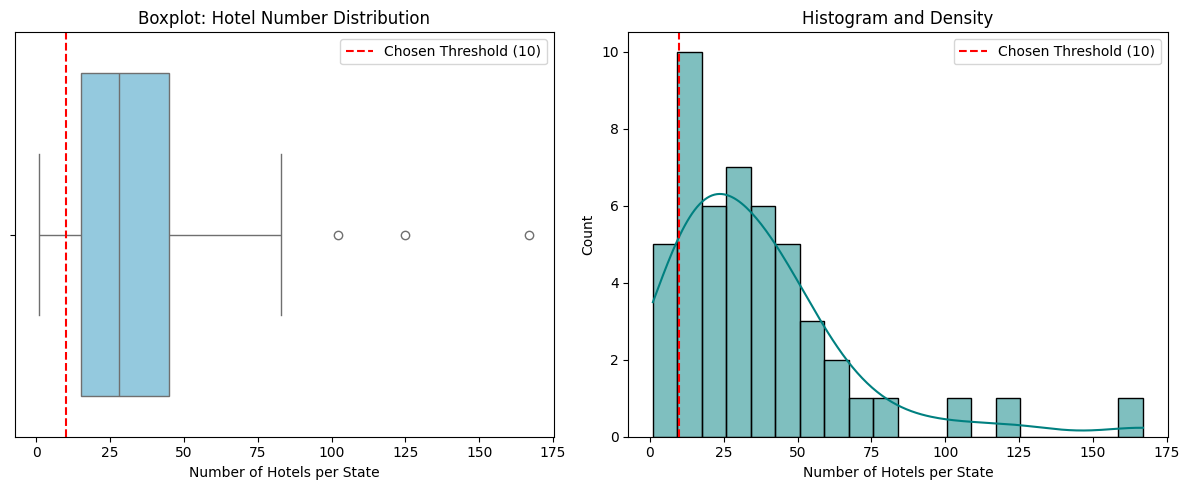

In [36]:
# 1. Calculating the distribution of the number of hotels for each state
hotel_counts = df.groupby('province')['name'].nunique()

# 2. Calculation of statistical parameters
min_val = hotel_counts.min()
q1 = hotel_counts.quantile(0.25)
mediana = hotel_counts.median()
media = hotel_counts.mean()
max_val = hotel_counts.max()

print("--- STATE DISTRIBUTION ANALYSIS ---")
print(f"Minimum number of hotels in a state: {min_val}")
print(f"First Quartile (25% of states have less than): {q1:.2f} hotels")
print(f"Median (50% of states have less than): {mediana:.2f} hotels")
print(f"Average hotels per state: {media:.2f}")
print(f"Maximum number of hotels: {max_val}")
print("-" * 45)
print(f"Choosing a threshold of 10 positions us close to the First Quartile (Q1),\n"
      f"effectively filtering out states in the lower tail of the distribution.")

# 3. Graphical Visualization (Boxplot and Distribution)
plt.figure(figsize=(12, 5))

# Boxplot to highlight quartiles and median
plt.subplot(1, 2, 1)
sns.boxplot(x=hotel_counts, color='skyblue')
plt.axvline(10, color='red', linestyle='--', label='Chosen Threshold (10)')
plt.title('Boxplot: Hotel Number Distribution')
plt.xlabel('Number of Hotels per State')
plt.legend()

# Density histogram to see the concentration
plt.subplot(1, 2, 2)
sns.histplot(hotel_counts, kde=True, color='teal', bins=20)
plt.axvline(10, color='red', linestyle='--', label='Chosen Threshold (10)')
plt.title('Histogram and Density')
plt.xlabel('Number of Hotels per State')
plt.legend()

plt.tight_layout()
plt.show()

State,Code,Average Rating,Hotel Count
Hawaii,HI,4.36,11
Idaho,ID,4.34,15
Connecticut,CT,4.30,10
New Mexico,NM,4.29,22
Massachusetts,MA,4.28,38
Missouri,MO,4.25,34
South Carolina,SC,4.24,41
Montana,MT,4.22,23
Washington,WA,4.21,45
Illinois,IL,4.21,65


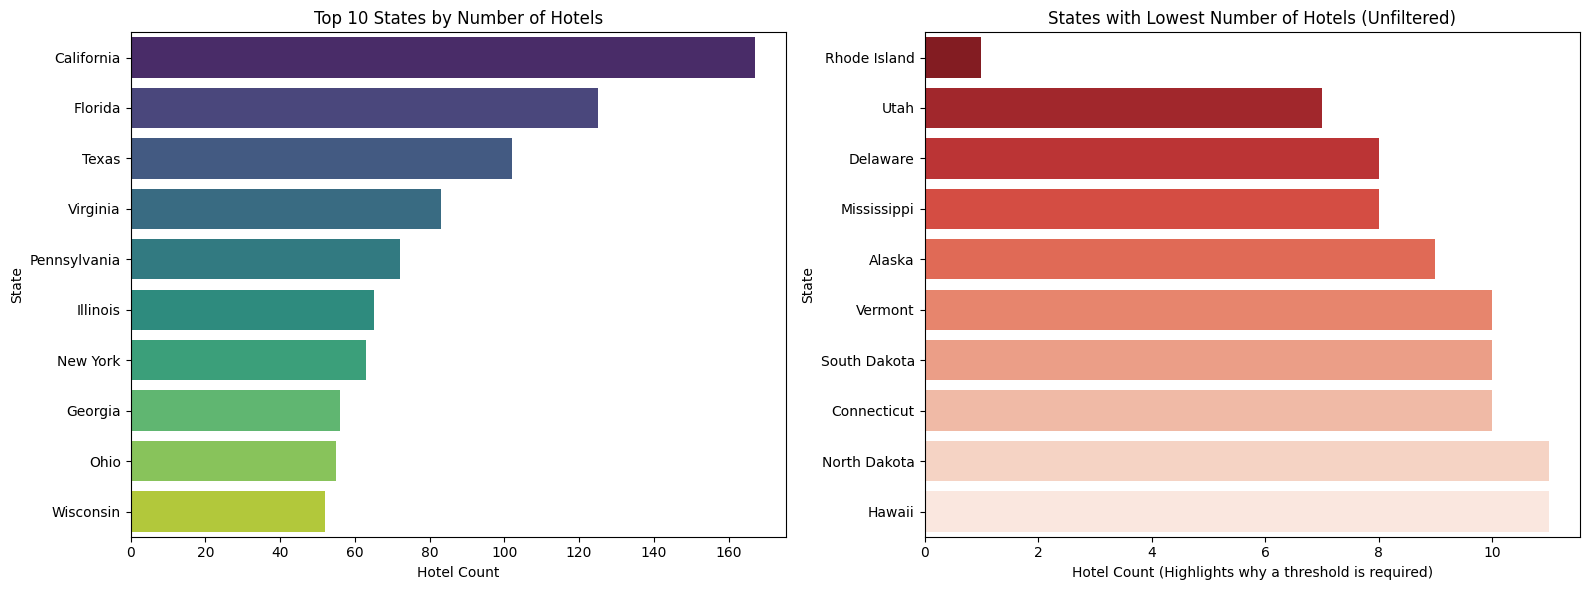

In [37]:
# --- 1. FULL DATA PREPROCESSING ---
# Calculate statistical summaries for all states
state_analysis_full = df.groupby('province').agg({
    'reviews.rating': 'mean',
    'name': 'nunique'
}).rename(columns={'reviews.rating': 'Average Rating', 'name': 'Hotel Count'})

state_analysis_full['State'] = state_analysis_full.index.map(abbrev_to_us_state)
state_analysis_full = state_analysis_full.reset_index().rename(columns={'province': 'Code'})

# Reorder columns
cols_order = ['State', 'Code', 'Average Rating', 'Hotel Count']
state_analysis_full = state_analysis_full[cols_order]

# --- 2. APPLYING FILTER FOR RATING TABLES (Threshold >= 10) ---
filtered_rating = state_analysis_full[state_analysis_full['Hotel Count'] >= 10].copy()

top_10_rating = filtered_rating.sort_values('Average Rating', ascending=False).head(10)
bottom_10_rating = filtered_rating.sort_values('Average Rating', ascending=True).head(10)

# --- 3. TABLE VISUALIZATION ---
style_config = {"Average Rating": "{:.2f}"}
t_top = top_10_rating.style.format(style_config).hide(axis="index").set_caption("🏆 TOP 10 RATING (Threshold >= 10)")
t_bot = bottom_10_rating.style.format(style_config).hide(axis="index").set_caption("🚩 BOTTOM 10 RATING (Threshold >= 10)")

display(HTML(f"""
<div style="display: flex; gap: 50px; align-items: flex-start;">
    <div>{t_top.to_html()}</div>
    <div>{t_bot.to_html()}</div>
</div>
"""))

# --- 4. BAR CHARTS (Volume Comparison) ---
# Top 10 by volume from full dataset
top_10_volume = state_analysis_full.sort_values('Hotel Count', ascending=False).head(10)

# Bottom 10 from UNFILTERED dataset (to show low volume)
bottom_10_unfiltered = state_analysis_full.sort_values('Hotel Count', ascending=True).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top Volume Graphic
sns.barplot(
    data=top_10_volume, x='Hotel Count', y='State',
    ax=axes[0], hue='State', palette='viridis', legend=False
)
axes[0].set_title('Top 10 States by Number of Hotels')
axes[0].set_xlabel('Hotel Count')
axes[0].set_ylabel('State')

# Bottom Volume Chart (WITHOUT THRESHOLD)
sns.barplot(
    data=bottom_10_unfiltered, x='Hotel Count', y='State',
    ax=axes[1], hue='State', palette='Reds_r', legend=False
)
axes[1].set_title('States with Lowest Number of Hotels (Unfiltered)')
axes[1].set_xlabel('Hotel Count (Highlights why a threshold is required)')
axes[1].set_ylabel('State')

plt.tight_layout()
plt.show()

The two tables illustrate the top 10 and bottom 10 states by average rating, applying a strict reliability threshold of at least 10 hotels per state. The average rating spans from a minimum of 3.51 to a maximum of 4.36. This narrow delta of less than a single point indicates a highly stable baseline across the nation: no single state performs critically below average, and all maintain satisfactory baseline scores. Conversely, no state achieves absolute excellence (scores exceeding 4.50), suggesting clear opportunities for quality optimization even among the top-tier regions.

The two accompanying bar charts visualize the volume distribution of hotels per state, emphasizing the statistical impact of filtering out low-volume regions. It is immediately clear that establishing a threshold was a methodological necessity; including a state like Rhode Island—represented by a single hotel—would yield statistically insignificant insights. The states falling below this 10-hotel threshold represent a negligible fraction of the data and do not compromise the integrity of the broader dataset. Finally, the right-hand chart highlights that premier tourism hubs are extensively represented, with California and Florida expectedly leading the national distribution.

## Web Sources and Platform Distribution

This section provides a focused analysis of the source websites from which the customer reviews were retrieved. The objective is to identify the most dominant platforms within the dataset and investigate whether specific web sources exhibit a structural bias toward significantly higher or lower user ratings.

In [40]:
# Uses the clean_url column created previously for the map and extracts the domain
df['review_provider'] = df['clean_url'].str.extract(r'https?://(?:www\.)?([^/]+)')[0].fillna("Unknown")

# Further cleaning (e.g. removing residual underlays)
df['review_provider'] = df['review_provider'].str.split(',').str[0].str.strip()

print("Top 10 Review Providers:")
print(df['review_provider'].value_counts().head(10))

Top 10 Review Providers:
review_provider
tripadvisor.com      5679
expedia.com          1831
booking.com          1222
hotels.com           1190
citysearch.com         21
insiderpages.com       15
tripadvisor.ca         14
yellowpages.com        13
theknot.com             9
tripadvisor.co.uk       2
Name: count, dtype: int64


Most of the reviews come from the first 4 sites on the list, so these 4 sites will be considered for the rating analysis.

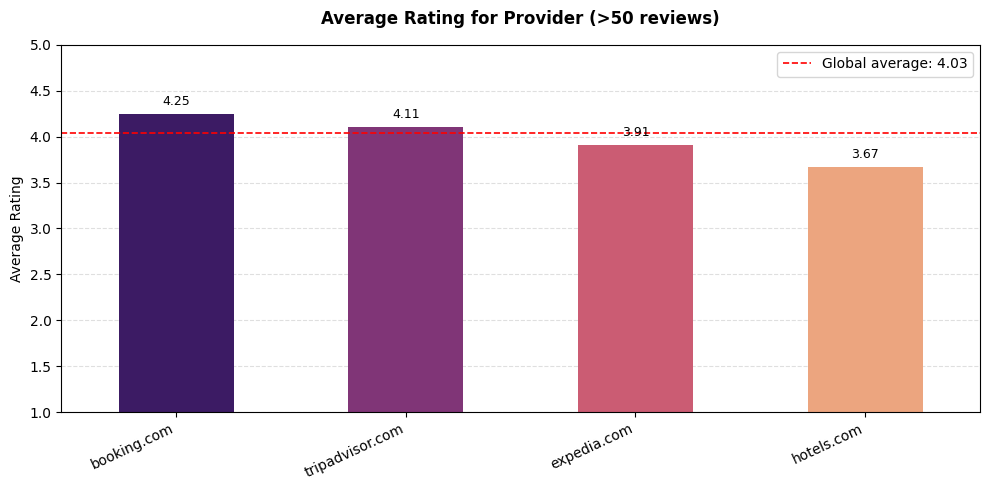

In [42]:
# 1. Data preparation
provider_stats = df.groupby('review_provider')['reviews.rating'].agg(['mean', 'count']).reset_index()
provider_stats = provider_stats[provider_stats['count'] > 500].sort_values(by='mean', ascending=False)

# 2. Plot
plt.figure(figsize=(10, 5))
ax = plt.gca()
ax.set_axisbelow(True)
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Bars
sns.barplot(
    data=provider_stats,
    x='review_provider',
    y='mean',
    hue='review_provider',
    palette='magma',
    legend=False,
    width=0.5
)

# 3. Global average calculated only once
avg_global = df['reviews.rating'].mean()
plt.axhline(avg_global, color='red', linestyle='--', linewidth=1.2, label=f'Global average: {avg_global:.2f}')

# 4. Graph appearance
plt.title('Average Rating for Provider (>50 reviews)', fontsize=12, fontweight='bold', pad=15)
plt.ylabel('Average Rating')
plt.xlabel(None)
plt.xticks(rotation=25, ha='right')
plt.ylim(1, 5)

# Values ​​above the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points',
                fontsize=9)

plt.legend(loc='upper right', frameon=True)
plt.tight_layout()
plt.show()

* **Rating Consistency.** It is interesting to note that the average ratings across different review providers heavily mirror the national state-level distribution analyzed previously. The lowest-performing platforms average around 3.50, while the top-performing ones hover around 4.30, positioning the overall provider mean directly in the center.
* **Platform Dominance.** TripAdvisor is by far the most heavily represented platform in the dataset, capturing over 5,500 hotel reviews, with an average score that aligns almost perfectly with the global baseline.
* **Review Behavior & Distribution.** A global average clustering around 4.0 suggests a distinct consumer behavior pattern: satisfied guests frequently award maximum scores (5 stars), whereas guests encountering issues rarely leave absolute minimum scores, generally stabilizing around 3 stars. This further reinforces the previous observation that extreme, worst-case operational scenarios remain relatively rare in this dataset.

## Text Analytics & Sentiment Analysis

This section shifts the analytical focus from numerical ratings to unstructured textual data. By extracting insights directly from the written reviews left by customers, we aim to uncover qualitative context that quantitative scores alone cannot capture. This approach helps identify the most prevalent operational pain points as well as the core strengths of the facilities, enabling more targeted, data-driven interventions.

### Exploratory Text Analysis & Tokenization
In this step, the raw review text is cleaned, normalized, and preprocessed to prepare the corpus for linguistic analysis.

In [45]:
# Fills empty titles with an empty string and merge columns
df['full_review'] = df['reviews.title'].fillna('') + " " + df['reviews.text'].fillna('')

# Basic cleaning: all lowercase and punctuation removal
df['full_review'] = df['full_review'].str.lower().str.replace(r'[^\w\s]', '', regex=True)

bad_reviews = df[df['reviews.rating'] <= 2]['full_review']
good_reviews = df[df['reviews.rating'] >= 4]['full_review']

In [46]:
# Groups of 2 words
def get_top_n_words(corpus, n=10):
    vec = CountVectorizer(ngram_range=(2, 2), stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    return sorted(words_freq, key = lambda x: x[1], reverse=True)[:n]

# Trigrams (ngram_range=(3, 3))
def get_top_trigrams(corpus, n=10):
    vec = CountVectorizer(ngram_range=(3, 3), stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    return sorted(words_freq, key = lambda x: x[1], reverse=True)[:n]


def find_context(corpus, target_word, window=2):
    context_list = []
    for text in corpus:
        words = text.split()
        if target_word in words:
            idx = words.index(target_word)
            # Take the 2 words before the target
            start = max(0, idx - window)
            context_list.append(" ".join(words[start:idx+1]))
    return pd.Series(context_list).value_counts().head(10)

In [47]:
print("Things that aren't right:", get_top_n_words(bad_reviews))
print("Strengths:", get_top_n_words(good_reviews))

Things that aren't right: [('customer service', 56), ('parking lot', 50), ('stay hotel', 44), ('room clean', 44), ('did work', 40), ('hot water', 38), ('worst hotel', 38), ('room smelled', 34), ('didnt work', 30), ('room room', 30)]
Strengths: [('staff friendly', 622), ('great location', 514), ('place stay', 491), ('room clean', 448), ('friendly staff', 403), ('friendly helpful', 372), ('nice hotel', 341), ('clean comfortable', 336), ('great hotel', 333), ('great stay', 320)]


In [48]:
# Trigram Analysis
print("Things that aren't right:", get_top_trigrams(bad_reviews))
print("Strengths:", get_top_trigrams(good_reviews))

Things that aren't right: [('room smelled like', 11), ('worst hotel experience', 8), ('worst hotel stayed', 8), ('poor customer service', 7), ('room did work', 6), ('taking time share', 6), ('bad customer service', 5), ('smelled like urine', 5), ('did clean room', 5), ('smelled like smoke', 5)]
Strengths: [('staff friendly helpful', 202), ('great place stay', 171), ('hotel great location', 80), ('room clean comfortable', 73), ('friendly helpful staff', 62), ('nice place stay', 58), ('clean staff friendly', 55), ('home away home', 54), ('highly recommend hotel', 48), ('hotel staff friendly', 48)]


In [49]:
print(find_context(bad_reviews, "work"))

did not work            34
that didnt work          3
lights didnt work        3
key didnt work           3
tv didnt work            3
wifi didnt work          2
ac didnt work            2
does not work            2
condition didnt work     1
need to work             1
Name: count, dtype: int64


#### Key Insights from N-gram and Contextual Analysis

* **Bigram Analysis (2-word groups).** Initial insights indicate general customer dissatisfaction regarding room conditions and broad operational malfunctions. Recurrent patterns also point toward staff-related issues and unpleasant odors.
* **Trigram Analysis (3-word groups).** Moving to trigrams provides significantly deeper granular context, exposing specific cleanliness issues, distinct odor complaints, and precise equipment failures.
* **The Specificity Asymmetry.** A striking behavioral pattern emerges when comparing sentiment profiles: negative feedback is exceptionally descriptive and highly specific (e.g., *"smelled like urine"*), whereas positive feedback remains heavily generic and homogenous (*"nice"*, *"great"*, *"friendly"*). This strongly suggests that dissatisfied customers feel compelled to thoroughly document their exact grievances, while satisfied guests tend to leave brief, surface-level praise without detailing their experience.

An additional deep-dive was conducted within negative reviews to map the exact linguistic context surrounding the word *"work"*, aiming to isolate what specific amenities failed most frequently.

The analysis reveals failures concentrated around standard room essentials: lighting, electronic key cards, televisions, Wi-Fi connectivity, and air conditioning (HVAC) units. From a business optimization perspective, these findings offer clear actionable avenues:
* **High-Capital Interventions.** Fixing air conditioning systems or structural HVAC overhauls represents a complex, capital-intensive investment that requires long-term planning.
* **Low-Hanging Fruit (Quick Wins).** Conversely, issues with lighting, key card functionality, and Wi-Fi stability are operational quick-fixes. Addressing these high-frequency, low-cost details immediately eliminates major triggers for negative reviews with minimal financial friction.

### Categorization of Customer Grievances
In this section, unstructured complaints are mapped into distinct thematic buckets. Categorizing these issues allows for a structured, comparative analysis of different operational pain points.

In [52]:
# 1. Filter for negative reviews only (e.g., rating <= 2)
bad_reviews = df[df['reviews.rating'] <= 2]['full_review']

# 2. Vectorizer with customized stopwords
# Appending 'hotel', 'room', etc., as they are ubiquitous and do not help differentiate topics
custom_stop_words = list(CountVectorizer(stop_words='english').get_stop_words()) + ['hotel', 'room', 'stay', 'just', 'did', 'rooms', 'night']

vectorizer = CountVectorizer(stop_words=custom_stop_words, max_features=1000, ngram_range=(1,2))
data_vectorized = vectorizer.fit_transform(bad_reviews)

# 3. Apply LDA (Extract 4 "macro-themes" of complaints)
lda = LatentDirichletAllocation(n_components=4, random_state=42)
lda.fit(data_vectorized)

# 4. Function to display topic extraction results
def print_top_words(model, feature_names, n_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print(f"\nCOMPLAINT CATEGORY #{topic_idx+1}:")
        print(", ".join([feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]))

print_top_words(lda, vectorizer.get_feature_names_out(), 8)




COMPLAINT CATEGORY #1:
old, like, place, stayed, clean, dirty, parking, good

COMPLAINT CATEGORY #2:
desk, told, check, said, booked, time, bed, experience

COMPLAINT CATEGORY #3:
dirty, bed, worst, bathroom, floor, didnt, door, desk

COMPLAINT CATEGORY #4:
breakfast, service, staff, good, customer, time, location, customer service


#### Interpretation of Complaint Clusters (LDA Output)

* **CATEGORY #1: Facilities & Maintenance (Visual & Structural Presentation).** Keywords like *old*, *dirty*, and *parking* indicate that guests perceive the property as dated, worn out, or poorly maintained.
* **CATEGORY #2: Front Desk & Communication (The Ingestion/Check-in Phase).** Keywords like *told*, *said*, *booked*, and *desk* point directly toward operational friction during the reservation or arrival process (e.g., miscommunications or unfulfilled promises).
* **CATEGORY #3: Critical Hygiene Issues (The Room Experience).** This represents severe operational failures: keywords like *dirty*, *bathroom*, *bed*, and *worst* isolate a cluster entirely dedicated to unacceptable cleanliness standards.
* **CATEGORY #4: Amenities & Staff (Value Proposition & Delivery).** Keywords like *breakfast*, *service*, and *location* suggest that while the foundational offerings are present, deficiencies in service execution (e.g., breakfast quality or service speed) compromised the guest experience.

#### Next Analytical Steps
This topic modeling provides a clear macro-overview of the primary operational pain points driving negative reviews: outdated infrastructure, front-desk miscommunications, critical cleaning failures, and sub-optimal service delivery.

To transition these insights into a definitive action plan, our next steps will explore:
1. **Frequency & Volume:** Which of these 4 issues is the most prevalent across the entire dataset?
2. **Geographical Variation:** Are specific complaints clustered in certain states?
3. **Rating Impact:** Which cluster has the most devastating impact on the final numerical score?
4. **Demographic Bias:** Do guests from certain geographic regions exhibit stricter evaluation criteria than others?

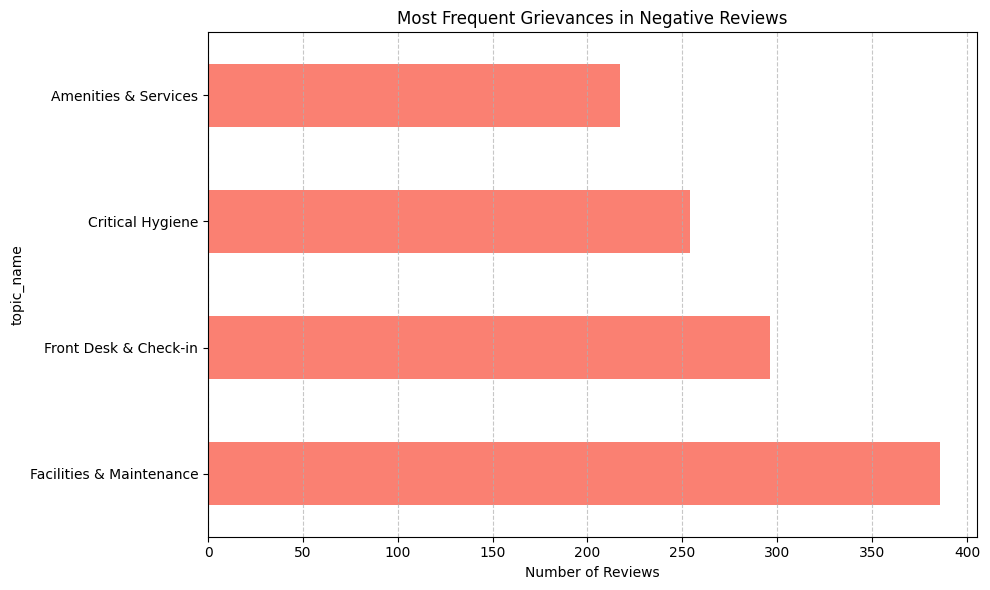

In [54]:
# -- BAR CHART ON CRITICAL COMPLAINT AREAS --

topic_values = lda.transform(data_vectorized)
df_bad = df[df['reviews.rating'] <= 2].copy()

# Assign the topic with the highest probability to each review
df_bad['dominant_topic'] = topic_values.argmax(axis=1) + 1

# Map topic numbers to descriptive English labels
topic_names = {
    1: "Facilities & Maintenance",
    2: "Front Desk & Check-in",
    3: "Critical Hygiene",
    4: "Amenities & Services"
}
df_bad['topic_name'] = df_bad['dominant_topic'].map(topic_names)

df_geo = df_bad[['province', 'latitude', 'longitude', 'topic_name', 'name']].copy()

# Drop rows with missing province to ensure clean geographic data for downstream analyses
df_geo = df_geo.dropna(subset=['province'])

# Calculate frequencies and generate the horizontal bar chart
topic_counts = df_bad['topic_name'].value_counts()

plt.figure(figsize=(10, 6))
topic_counts.plot(kind='barh', color='salmon')
plt.title('Most Frequent Grievances in Negative Reviews')
plt.xlabel('Number of Reviews')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

This chart clearly illustrates how guest complaints are distributed across different functional areas, providing critical insights into where operational interventions are most urgently required:

* **Facilities & Maintenance (Highest Frequency).** This is the most prevalent issue, likely driven by aging properties and insufficient structural renovations over the years. While this area accumulates the highest volume of negative feedback, it is also the most challenging to resolve, as structural overhauls and property renovations require significant capital expenditures and long-term planning.
* **Front Desk & Check-in (Operational Execution).** In contrast, friction during the check-in and booking phases depends heavily on internal organization, workflow optimization, and staff training—variables that management can directly influence and correct with immediate effect.
* **Amenities & Services (Lowest Frequency).** This category receives the fewest complaints and represents the lowest risk to reputation, provided that the hotel's pricing strategy remains fairly aligned with the scope of services offered.
* **Critical Hygiene (The Zero-Tolerance Threshold).** Cleanliness stands out as the ultimate deal-breaker. While guests are often willing to tolerate dated infrastructure or limited amenities if the price is right, sub-optimal hygiene is an uncompromisable failure that permanently destroys customer retention.

From a consumer behavior perspective, prospective guests reading reviews face a clear hierarchy of needs: a traveler will consistently choose an *“outdated but impeccably clean”* property over a *“brand new hotel with poor housekeeping standards.”* Therefore, ensuring strict cleanliness protocols must be treated as the highest operational priority.

In [56]:
# Filter for hotels with a baseline of negative reviews to ensure a minimum statistical sample
hotel_stats = df_bad.groupby('name').agg({
    'id': 'count',
    'dominant_topic': lambda x: (x == 3).sum() # Count occurrences of Critical Hygiene (Topic 3)
})

hotel_stats.columns = ['tot_negative_reviews', 'hygiene_issues']
hotel_stats['hygiene_impact_pct'] = (hotel_stats['hygiene_issues'] / hotel_stats['tot_negative_reviews'] * 100).round(1)

# Isolate hotels with at least 3 specific hygiene complaints, sorted by percentage impact
worst_hygiene_hotels = hotel_stats[hotel_stats['hygiene_issues'] >= 3].sort_values(by='hygiene_impact_pct', ascending=False)

print("Top 10 Hotels with Worst HYGIENE Grievances (Relative to their total negative reviews):")
print(worst_hygiene_hotels[['hygiene_issues', 'hygiene_impact_pct']].head(10))

Top 10 Hotels with Worst HYGIENE Grievances (Relative to their total negative reviews):
                                                    hygiene_issues  \
name                                                                 
Days Inn Elk Grove Village/chicago/ohare Airpor...               3   
Rodeway Inn Suites                                               4   
Red Roof Inn Fresno - Yosemite Gateway                           4   
Red Roof Inn & Suites Newark-university                          6   
The Annex at The Chelsea                                         5   
Best Western Capital Beltway                                     5   
Baymont Inn & Suites Celebration                                 3   
Days Inn Baltimore South/Glen Burnie                             6   
Extended Stay America Washington, D.C. - Spring...               3   
La Quinta Inn Norfolk Virginia Beach                             4   

                                                    hygiene_impact_pct 

This section provides a targeted list of the lowest-performing hotels regarding hygiene standards, effectively isolating the specific properties that represent critical outliers to avoid.

### Geographic Heatmap Analysis
The objective of this heatmap is to evaluate the relative distribution and operational impact of the four primary complaint categories across the top 15 states with the highest hotel density.

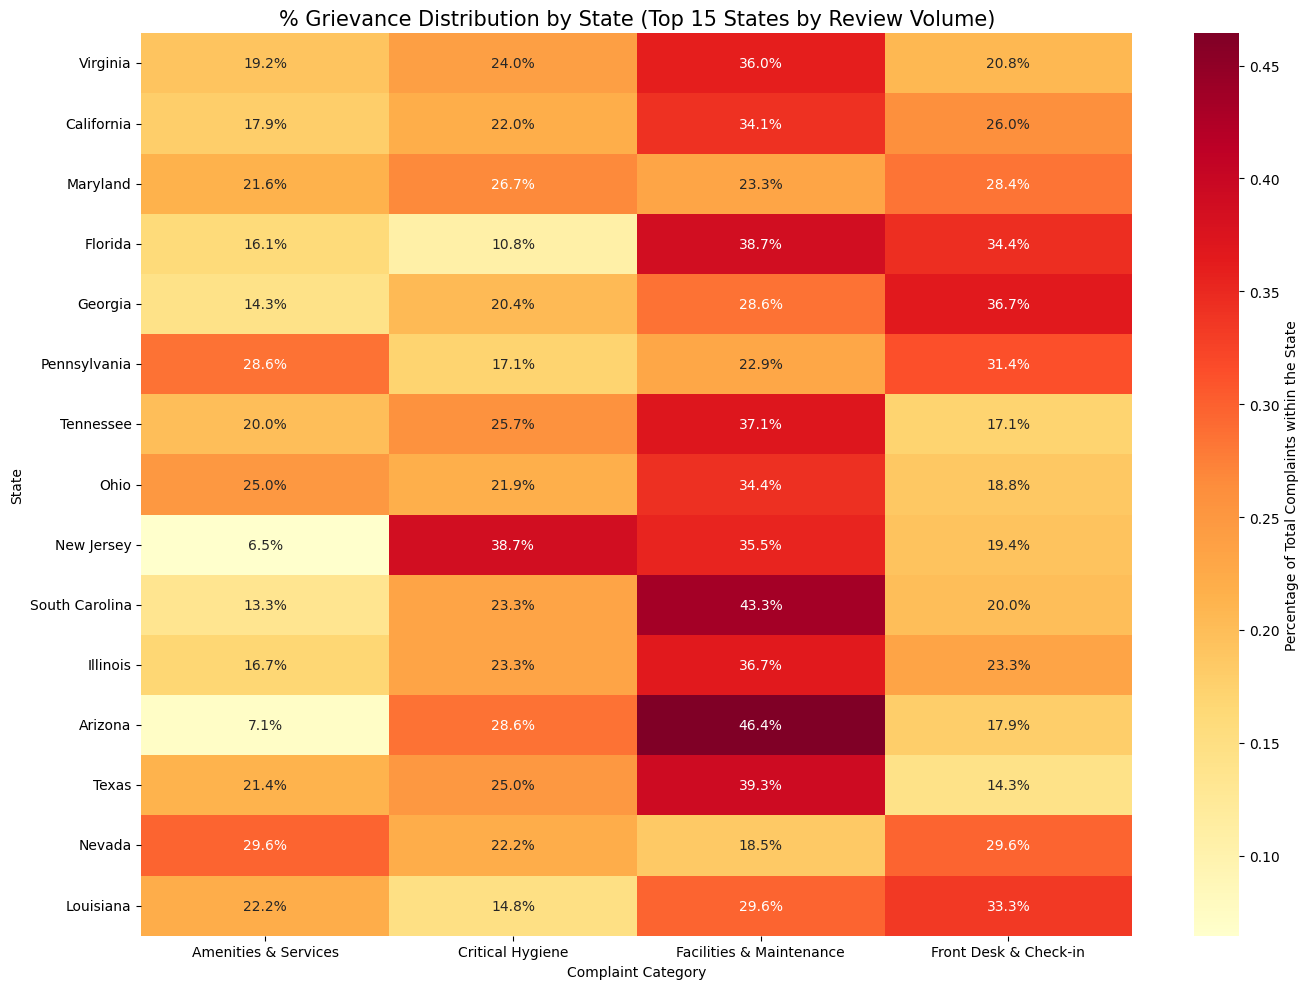

In [59]:
df_geo_clean = df_geo.copy()
df_geo_clean['province_full'] = df_geo['province'].map(abbrev_to_us_state)

# 1. Generate the pivot table with raw counts
geo_pivot = df_geo_clean.pivot_table(index='province_full', columns='topic_name', aggfunc='size', fill_value=0)

# 2. Sort states by total volume to keep the most relevant ones at the top
geo_pivot = geo_pivot.loc[geo_pivot.sum(axis=1).sort_values(ascending=False).index]

# 3. PERCENTAGE TRANSFORMATION (Row-wise normalization):
# Divide each value by the total of its respective row to find relative impact
geo_pivot_pct = geo_pivot.div(geo_pivot.sum(axis=1), axis=0)

# 4. Select the top 15 states to ensure map readability
geo_pivot_top_pct = geo_pivot_pct.head(15)

# Visualization Setup
plt.figure(figsize=(14, 10))
sns.heatmap(geo_pivot_top_pct,
            annot=True,          # Display values inside cells
            fmt=".1%",           # Format values as percentages with one decimal place
            cmap='YlOrRd',       # Yellow-to-Red color palette
            cbar_kws={'label': 'Percentage of Total Complaints within the State'})

plt.title('% Grievance Distribution by State (Top 15 States by Review Volume)', fontsize=15)
plt.ylabel('State')
plt.xlabel('Complaint Category')
plt.tight_layout()
plt.show()

#### Insights from Geographic Heatmap Analysis

The row-normalized heatmap reveals distinct regional variations and strategic insights across the top 15 states:

* **Facilities & Maintenance (Dominant Trend).** In line with the aggregate data, structural issues represent the highest relative percentage of complaints across almost all regions. Arizona and South Carolina emerge as the primary outliers, showing the highest concentration of infrastructure-related grievances.
* **Amenities & Services (Uniform High Performance).** Complaints regarding hotel services are distributed fairly evenly nationwide. Notably, New Jersey and Arizona display exceptionally low percentage shares in this category, indicating strong operational performance and guest satisfaction regarding their service offerings.
* **Critical Hygiene (The Impact Driver).** New Jersey stands out with the highest proportion of cleanliness complaints. This directly correlates with our previous finding where New Jersey registered the lowest aggregate average rating (3.51), heavily reinforcing the hypothesis that hygiene failure is the strongest driver of negative ratings. Conversely, Florida emerges as a benchmark leader in this category, with hygiene grievances accounting for only 10.8% of its total complaints.
* **Front Desk & Check-in (Stable Distribution).** Issues linked to management and check-in workflows show a highly uniform distribution across all analyzed states, firmly contained within a stable 10% to 40% range with no radical outliers.

In [61]:
# Calculate the average rating for each unique hotel from the original dataframe
hotel_ratings = df.groupby('name')['reviews.rating'].mean().round(2)

# Join the average global rating with our previous hygiene statistics
worst_hygiene_hotels = worst_hygiene_hotels.join(hotel_ratings)

# Define advanced styling properties for the DataFrame visualization
styled_table = worst_hygiene_hotels[['hygiene_issues', 'hygiene_impact_pct', 'reviews.rating']].head(15).style \
    .background_gradient(subset=['hygiene_impact_pct'], cmap='OrRd') \
    .background_gradient(subset=['reviews.rating'], cmap='RdYlGn_r') \
    .format({'hygiene_impact_pct': '{:.1f}%', 'reviews.rating': '{:.2f}'}) \
    .set_caption("Hygiene-Critical Hotels: Percent Impact vs. Global Average Rating") \
    .set_properties(**{'text-align': 'center', 'border': '1px solid white'})

styled_table

,hygiene_issues,hygiene_impact_pct,reviews.rating
name,,,
Days Inn Elk Grove Village/chicago/ohare Airport West,3,100.0%,1.00
Rodeway Inn Suites,4,66.7%,2.20
Red Roof Inn Fresno - Yosemite Gateway,4,66.7%,2.20
Red Roof Inn & Suites Newark-university,6,60.0%,3.19
The Annex at The Chelsea,5,41.7%,2.00
Best Western Capital Beltway,5,38.5%,3.35
Baymont Inn & Suites Celebration,3,37.5%,3.59
Days Inn Baltimore South/Glen Burnie,6,37.5%,3.19
"Extended Stay America Washington, D.C. - Springfield",3,37.5%,2.83


The table shows the top 15 hotels with the most cleanliness complaints compared to the total number of complaints. A rating column has been added next to it to demonstrate that properties with significant cleanliness issues often also have very low scores.

#### Location of hotels with cleaning issues

In [64]:
# Retrieve average geographic coordinates for each hotel
hotel_coords = df.groupby('name').agg({
    'latitude': 'mean',
    'longitude': 'mean'
}).join(worst_hygiene_hotels, how='inner')

# Initialize the interactive Folium map centered on the US
m = folium.Map(location=[37.0902, -95.7129], zoom_start=4, tiles='CartoDB positron')

for name, row in hotel_coords.iterrows():
    # Scale marker radius dynamically based on the volume of hygiene complaints
    radius = row['hygiene_issues'] * 2
    popup_text = f"<b>Hotel:</b> {name}<br><b>Average Rating:</b> {row['reviews.rating']:.1f}<br><b>Hygiene Impact:</b> {row['hygiene_impact_pct']}%"

    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=radius,
        popup=folium.Popup(popup_text, max_width=300),
        color='crimson', fill=True, fill_color='crimson', fill_opacity=0.6
    ).add_to(m)

m

There's a cluster in the northeast, where the most densely populated areas of the country and the oldest buildings are located. Prices are probably also higher. The other hotels are scattered around the country; you can't see any other specific areas. None are outside the continental United States.

### Grievance Distribution Across US Regions

This section utilizes pie charts to visualize the relative impact and distribution of the four core complaint areas across the major geographic regions of the country.

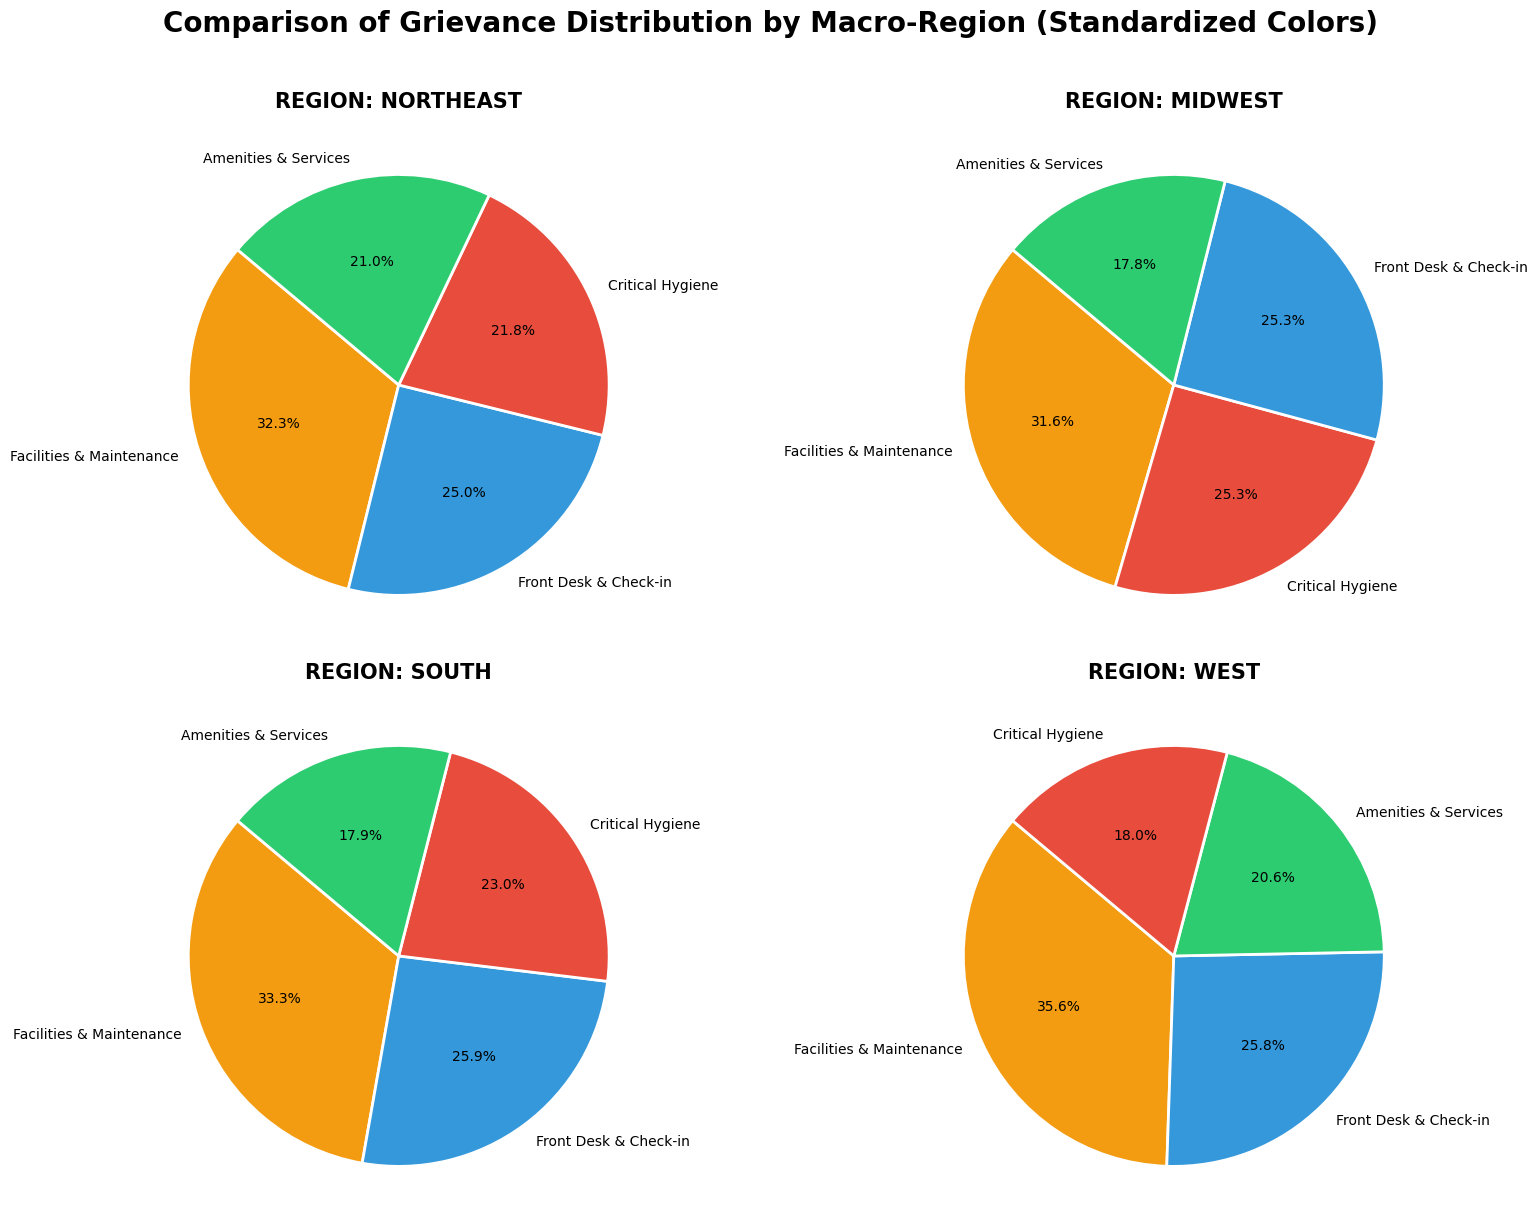

In [67]:
# Macro-Regions Assignment
# Official mapping by the US Census Bureau
regions = {
    'Northeast': ['CT', 'ME', 'MA', 'NH', 'RI', 'VT', 'NJ', 'NY', 'PA'],
    'Midwest': ['IL', 'IN', 'MI', 'OH', 'WI', 'IA', 'KS', 'MN', 'MO', 'NE', 'ND', 'SD'],
    'South': ['AL', 'AR', 'DE', 'FL', 'GA', 'KY', 'LA', 'MD', 'MS', 'NC', 'OK', 'SC', 'TN', 'TX', 'VA', 'WV', 'DC'],
    'West': ['AK', 'AZ', 'CA', 'CO', 'HI', 'ID', 'MT', 'NV', 'NM', 'OR', 'UT', 'WA', 'WY']
}

# Standardized color mapping definition (Color -> Category)
category_colors = {
    "Critical Hygiene": "#e74c3c",          # Red
    "Facilities & Maintenance": "#f39c12",  # Orange
    "Front Desk & Check-in": "#3498db",     # Blue
    "Amenities & Services": "#2ecc71"       # Green
}

# Function to assign the US Census region based on state abbreviation
def get_census_region(state):
    for region, states in regions.items():
        if state in states:
            return region
    return 'Other'

df_bad['macro_region'] = df_bad['province'].apply(get_census_region)


# Subplot layout configuration for the 4 macro-regions
region_list = ['Northeast', 'Midwest', 'South', 'West']
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, region in enumerate(region_list):
    data = df_bad[df_bad['macro_region'] == region]['topic_name'].value_counts()

    if not data.empty:
        # Align colors with the order of labels present in 'data'
        current_colors = [category_colors[label] for label in data.index]

        axes[i].pie(data,
                    labels=data.index,
                    autopct='%1.1f%%',
                    startangle=140,
                    colors=current_colors,
                    wedgeprops={'edgecolor': 'white', 'linewidth': 2})

        axes[i].set_title(f'REGION: {region.upper()}', fontsize=15, fontweight='bold', pad=10)
    else:
        axes[i].text(0.5, 0.5, 'Data not available', ha='center')

plt.suptitle('Comparison of Grievance Distribution by Macro-Region (Standardized Colors)',
             fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

As previously established, **Facilities & Maintenance** consistently emerges as the primary source of guest dissatisfaction across all areas. Regionally, the **Midwest** stands out with a pronounced concentration of critical hygiene grievances, validating our prior heatmap findings. Conversely, metrics surrounding **Front Desk & Check-in** exhibit remarkable nationwide stability, capturing a uniform 25% to 26% share of complaints across all four macro-regions.

---



## Traveler Demographics & Review Origin

This section shifts the analysis toward customer segmentation by examining the geographic origin of the travelers leaving feedback. By mapping their distribution and identifying which traveler cohorts exhibit the strictest rating criteria, this analysis provides dual business value:
* **Strategic Marketing:** It enables the design of targeted marketing campaigns tailored to specific high-yield or underrepresented regions.
* **Operational Insights:** It isolates regions where travelers display the highest average satisfaction, helping uncover geographic variations in customer expectations.

In [70]:
# Unify abbreviation-to-name and name-to-name dictionaries to map all inputs to their full state name
full_normalization_map = {**abbrev_to_us_state, **{k: k for k in us_state_to_abbrev.keys()}}

def clean_province(val):
    if pd.isna(val):
        return "Unknown"

    val = str(val).strip() # Remove leading/trailing whitespaces

    # 1. Standardize country-level entries to a generic USA label
    if val.lower() in ['united states', 'us', 'usa']:
        return "USA (Generic)"

    # 2. Match against the unified US states mapping dictionary
    if val in full_normalization_map:
        return full_normalization_map[val]

    # 3. Categorize non-US locations as International
    return "International"

# Apply the normalization logic to the dataset
df['user_origin_final'] = df['reviews.userProvince'].apply(clean_province)

# Display the resulting distribution
print(df['user_origin_final'].value_counts())

user_origin_final
Unknown           7295
International      271
California         233
Florida            198
Texas              178
New York           116
Pennsylvania       101
Illinois            97
Georgia             92
Ohio                80
Wisconsin           71
Washington          70
Michigan            70
Arizona             68
North Carolina      66
Massachusetts       64
Tennessee           60
Colorado            59
Missouri            52
Virginia            52
Maryland            48
Minnesota           48
Oregon              48
South Carolina      48
New Jersey          44
Indiana             43
Kansas              38
Nevada              37
Kentucky            32
Oklahoma            29
Iowa                27
Connecticut         24
Louisiana           23
Idaho               22
Alabama             22
Utah                20
West Virginia       19
Nebraska            18
Arkansas            16
New Mexico          15
New Hampshire       11
Montana              9
Vermont         

### Key Insights on Traveler Origins & Data Limitations

A primary observation is the high volume of missing data, with over 7,000 entries classified as *Unknown*—a substantial portion relative to the overall dataset. Consequently, while the geographical insights regarding traveler sentiment provide valuable signals, they must be treated as preliminary and incomplete.







In [72]:
df_known = df[df['user_origin_final'] != 'Unknown'].copy()

# Calculate average rating and review count by traveler origin
provenance_rating = df_known.groupby('user_origin_final')['reviews.rating'].agg(['mean', 'count'])

# Filter for origins with a significant baseline (more than 20 reviews) and sort by mean rating
provenance_rating = provenance_rating[provenance_rating['count'] > 20].sort_values(by='mean')

print("Top 5 States with the STRICTEST Travelers (Lowest average ratings given):")
print(provenance_rating.head(5))

print("\nTop 5 States with the MOST LENIENT Travelers (Highest average ratings given):")
print(provenance_rating.tail(5))

Top 5 States with the STRICTEST Travelers (Lowest average ratings given):
                       mean  count
user_origin_final                 
Kansas             3.526316     38
Colorado           3.779661     59
Tennessee          3.783333     60
Alabama            3.818182     22
Minnesota          3.875000     48

Top 5 States with the MOST LENIENT Travelers (Highest average ratings given):
                       mean  count
user_origin_final                 
Virginia           4.288462     52
Oregon             4.291667     48
Missouri           4.307692     52
Louisiana          4.434783     23
Connecticut        4.500000     24


Among the valid samples, travelers from **Kansas** emerge as the most critical and strictest reviewers, whereas guests from **Connecticut** are the most enthusiastic, averaging a high score of 4.5. For a more comprehensive global benchmark, capturing a higher volume of international reviews would be highly beneficial to evaluate whether these domestic properties meet international hospitality standards.

---

## Conclusions & Strategic Recommendations

This notebook analyzed a comprehensive dataset of US hotel reviews to evaluate the general state of the hospitality sector and propose data-driven strategies for service optimization. While the dataset contains a robust feature set suitable for statistical analysis, it represents a sample size of approximately 10,000 reviews across 1,600 hotels—a small fraction of the vast US hospitality market. Additionally, the temporal scope of the data reflects historical trends from a few years ago. Despite these baseline constraints, the analysis yielded highly actionable operational insights:

* **Geographic Mapping:** An interactive map was developed to visualize property distribution nationwide, immediately identifying high-density clusters and regional performance baselines.
* **Platform Distribution:** An evaluation of the review sources identified four dominant online platforms capturing the vast majority of user feedback.
* **Text Mining & Sentiment Drivers:** Natural Language Processing (NLP) techniques extracted high-frequency keywords, isolating the core positive and negative drivers of the guest experience.
* **Advanced Topic Modeling (LDA):** Unsupervised learning successfully clustered negative feedback into four distinct macro-areas of complaint, mapping their specific proportional impact across geographic regions.
* **Demographic Segmentation:** An investigation into traveler origins was initiated, highlighting the critical need for cleaner data capture regarding user demographics in future iterations.

### Final Strategic Takeaways

The overarching synthesis of this research indicates that a significant portion of the analyzed inventory consists of aging infrastructure. These dated properties are not only perceived as worn out by guests but likely suffer from structural energy inefficiencies.

However, the ultimate driver of negative ratings remains **critical hygiene and cleanliness failures**, which permanently damage property scores and customer retention. Regionally, the **Midwest** emerges as the primary geographic area experiencing this dual challenge of aging infrastructure combined with high cleanliness friction.

**Strategic Recommendations:**
1. **Immediate Operational Priority:** Management must enforce stricter housekeeping protocols and quality control. Cleanliness is an uncompromisable threshold; resolving hygiene issues yields the highest and fastest return on investment (ROI) for overall rating improvement.
2. **The Eco-Hotel Transition:** Shifting toward sustainable, net-zero "eco-hotels" represents a highly profitable long-term strategy but involves a complex capital expenditure (CapEx) challenge. Since much of the current infrastructure is dated, achieving zero-impact operations will require significant, phased investments in structural retrofitting and modern energy systems.